Health Analytics: Analyze the correlation between different health metrics (e.g., BMI, HbA1c level) and diabetes.
Demographic Studies: Examine the distribution of diabetes across different demographic groups and locations.
Public Health Research: Identify risk factors for diabetes and target interventions to high-risk groups.
Clinical Research: Study the relationship between comorbid conditions like hypertension and heart disease with diabetes.


Descriptive Statistics: Summarize the dataset to understand the central tendencies and dispersion of features.
Correlation Analysis: Identify the relationships between features.
Trend Analysis: Analyze trends over the years to see how diabetes prevalence has changed.

In [ ]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


path = "data/diabetes_dataset.csv"
df = pd.read_csv(path)

In [10]:
df

,year,gender,age,location,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes
0,2020,Female,32.0,Alabama,0,0,0,0,1,0,0,never,27.32,5.0,100,0
1,2015,Female,29.0,Alabama,0,1,0,0,0,0,0,never,19.95,5.0,90,0
2,2015,Male,18.0,Alabama,0,0,0,0,1,0,0,never,23.76,4.8,160,0
3,2015,Male,41.0,Alabama,0,0,1,0,0,0,0,never,27.32,4.0,159,0
4,2016,Female,52.0,Alabama,1,0,0,0,0,0,0,never,23.75,6.5,90,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,2018,Female,33.0,Wyoming,0,0,0,0,1,0,0,never,21.21,6.5,90,0
99996,2016,Female,80.0,Wyoming,0,1,0,0,0,0,0,No Info,36.66,5.7,100,0
99997,2018,Male,46.0,Wyoming,0,1,0,0,0,0,0,ever,36.12,6.2,158,0
99998,2018,Female,51.0,Wyoming,1,0,0,0,0,0,0,not current,29.29,6.0,155,0


In [85]:
df.columns

Index(['year', 'gender', 'age', 'location', 'race:AfricanAmerican',
       'race:Asian', 'race:Caucasian', 'race:Hispanic', 'race:Other',
       'hypertension', 'heart_disease', 'smoking_history', 'bmi',
       'hbA1c_level', 'blood_glucose_level', 'diabetes'],
      dtype='str')

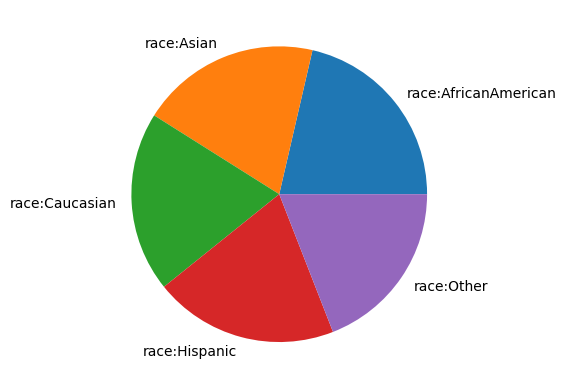

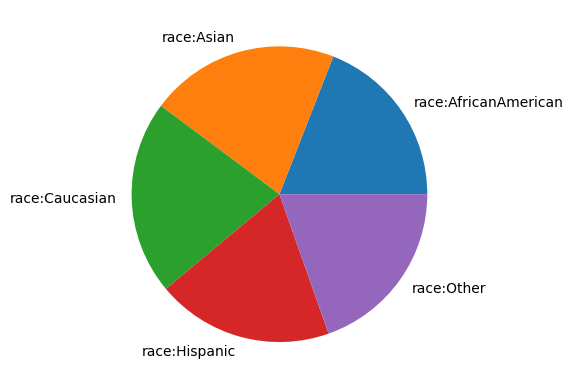

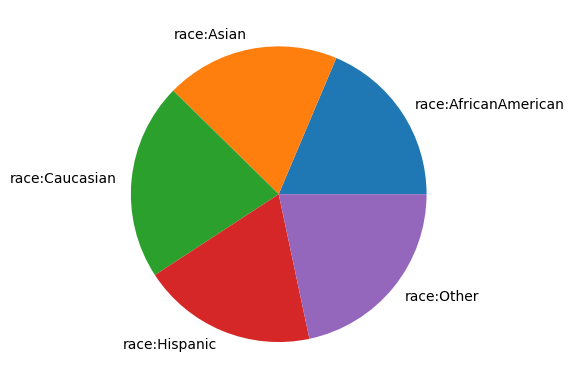

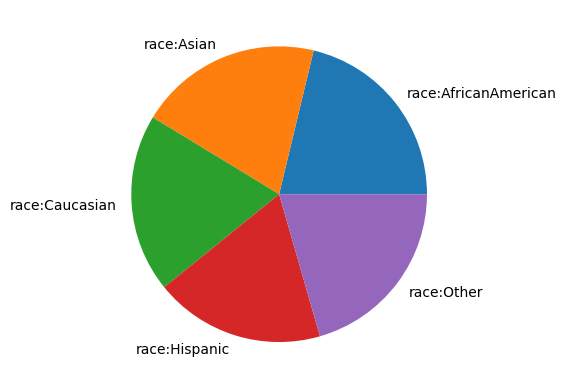

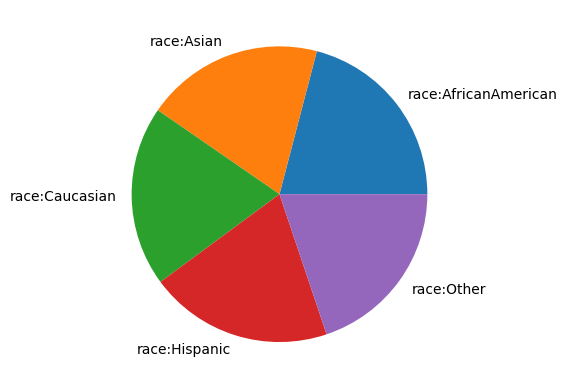

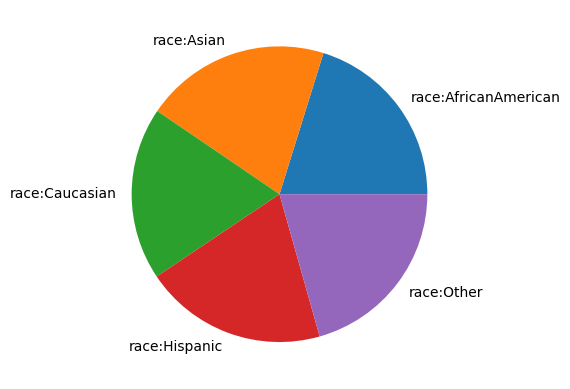

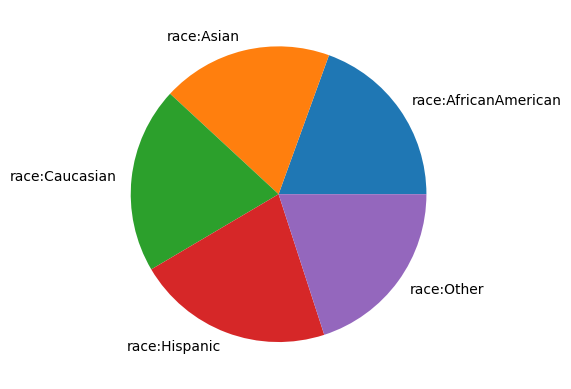

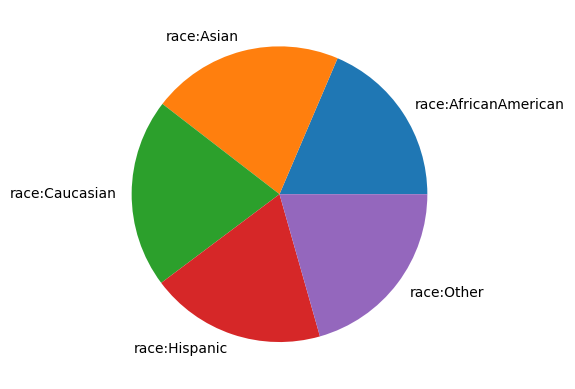

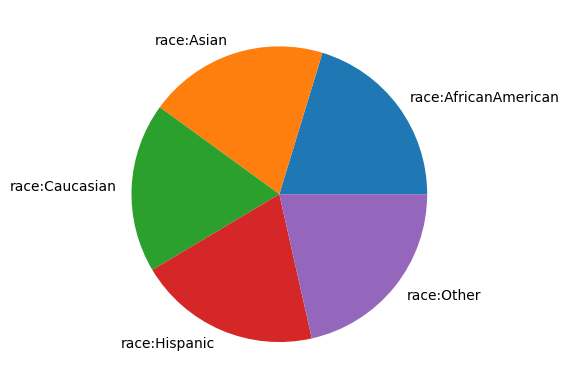

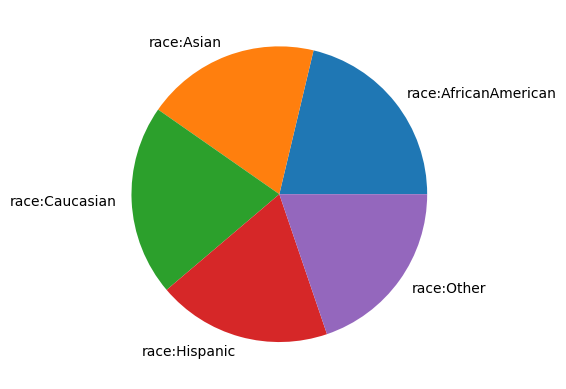

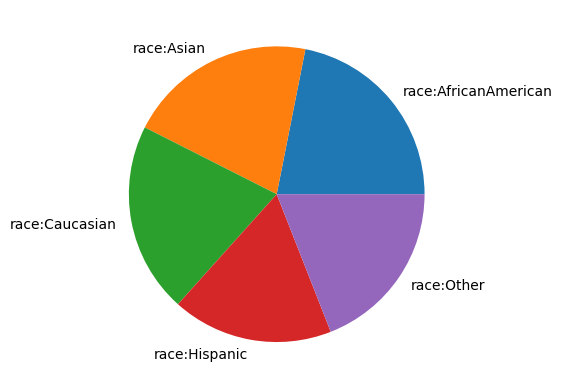

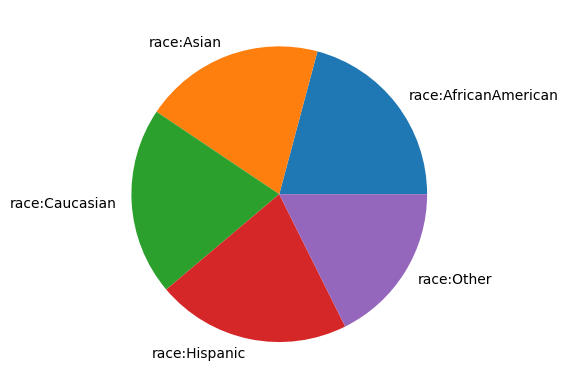

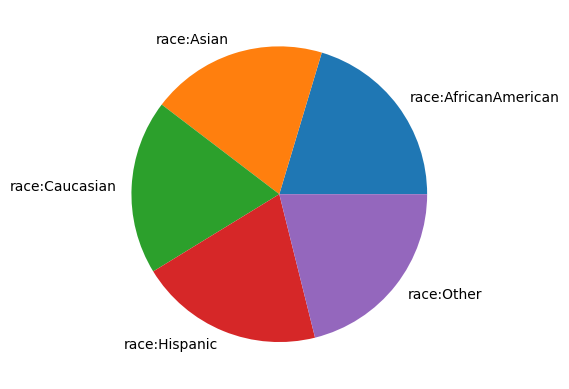

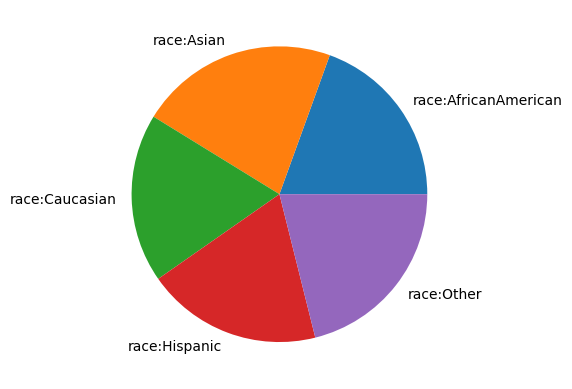

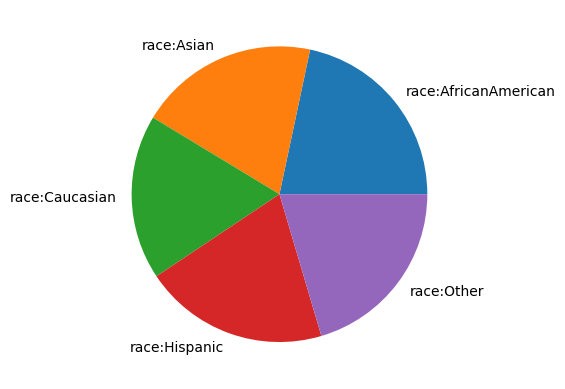

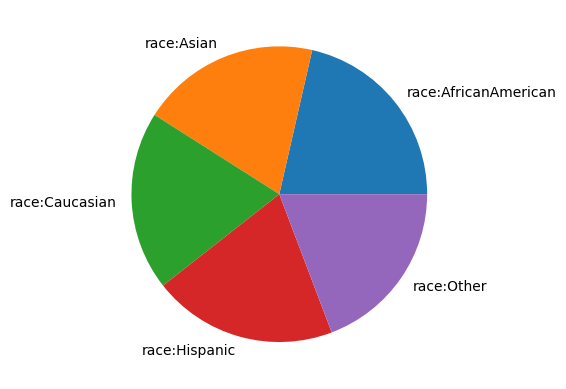

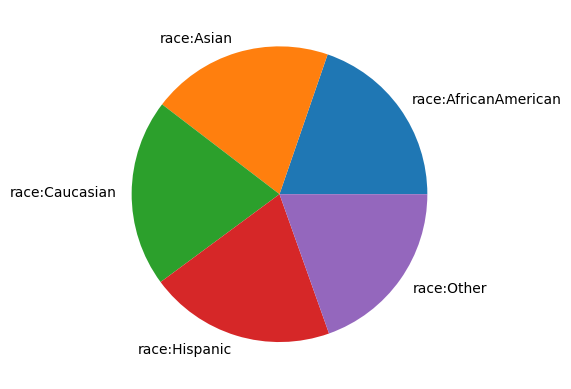

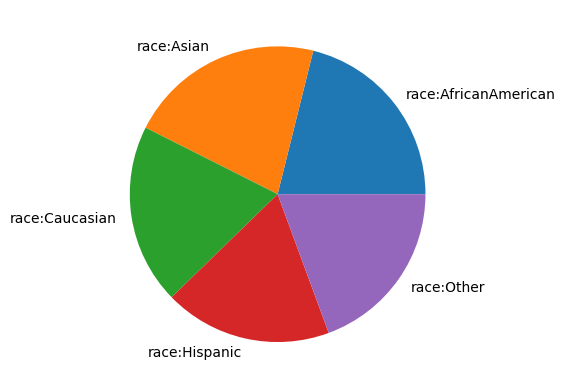

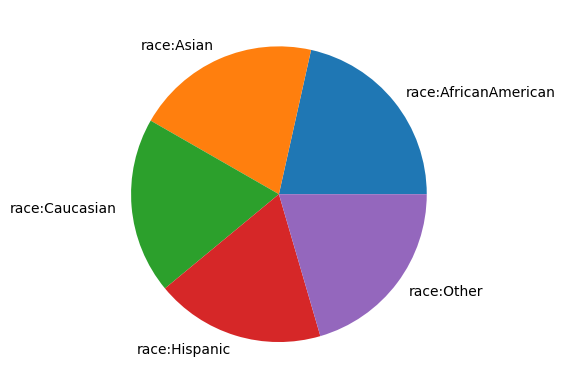

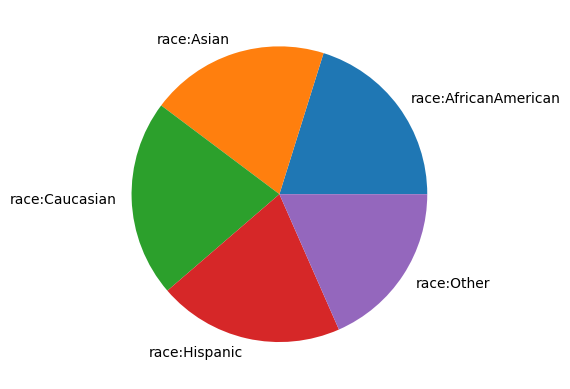

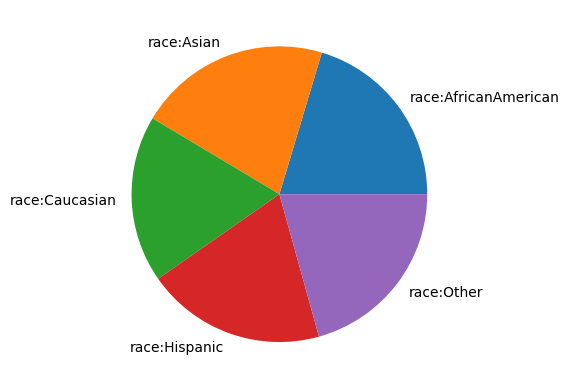

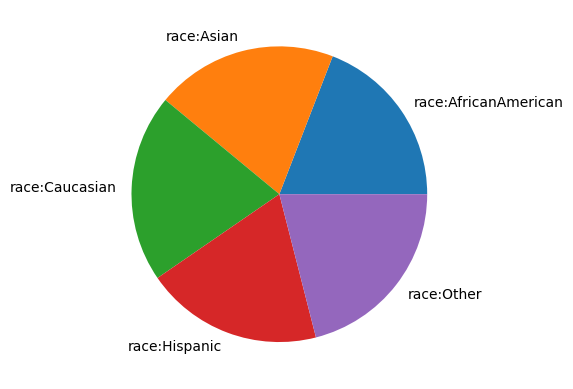

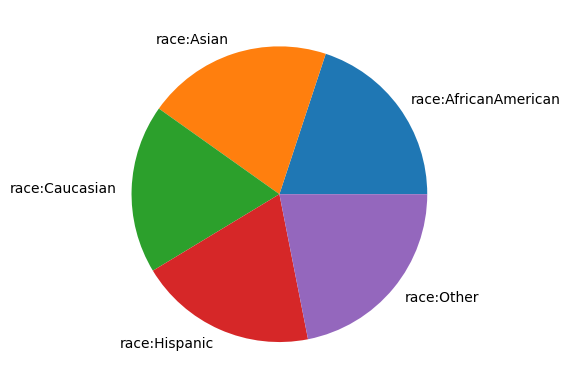

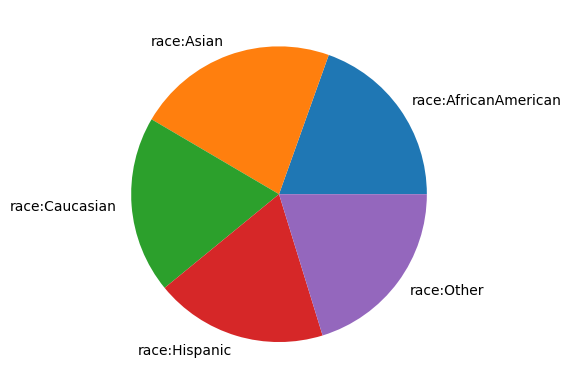

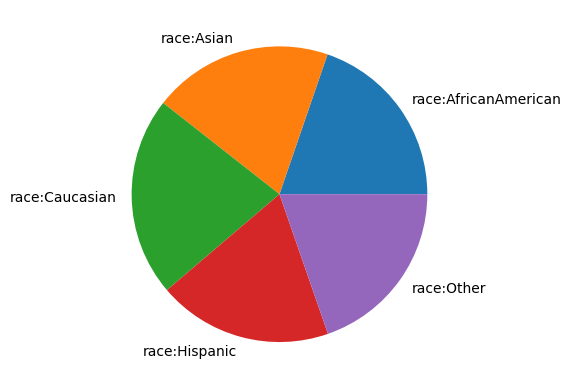

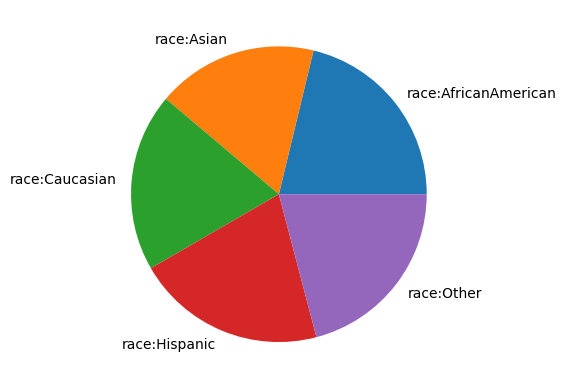

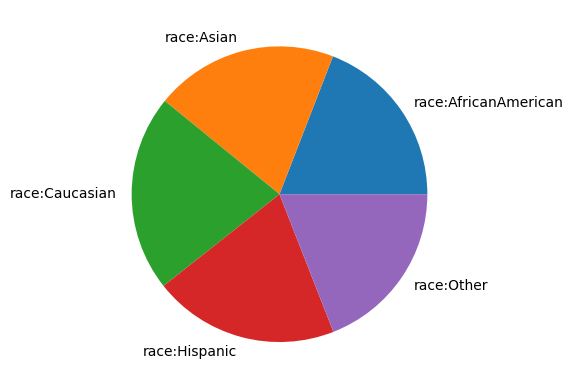

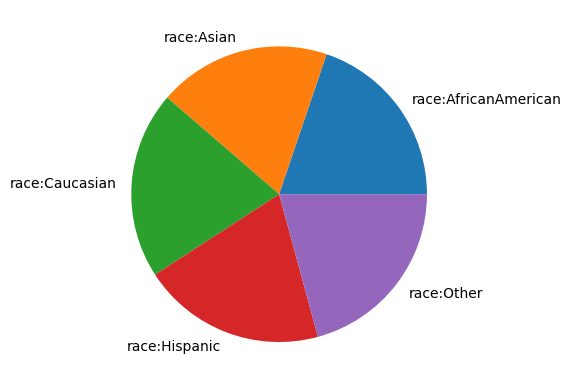

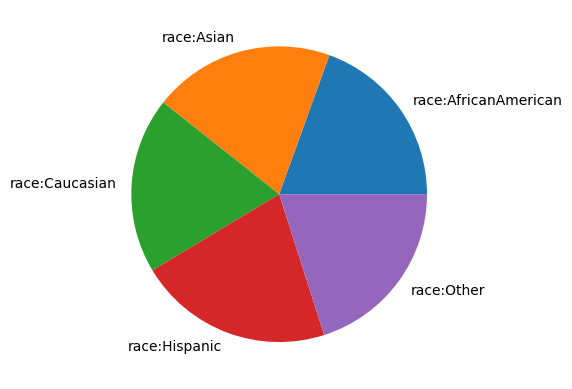

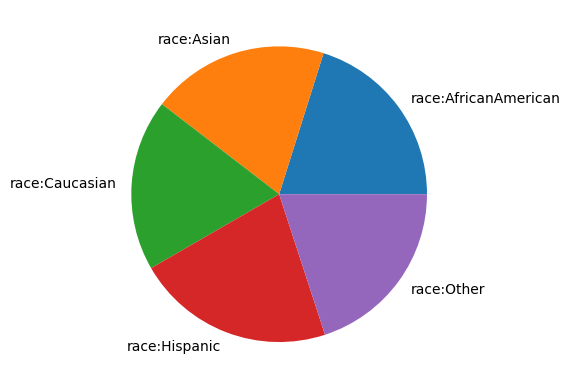

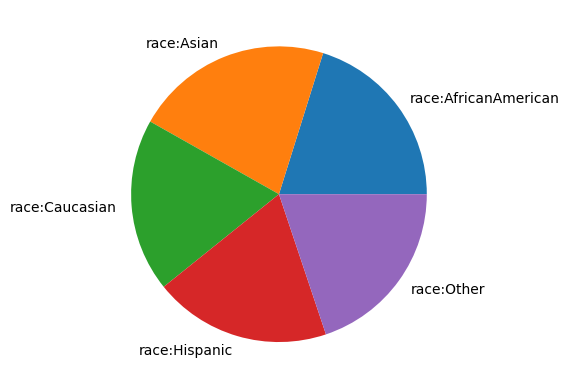

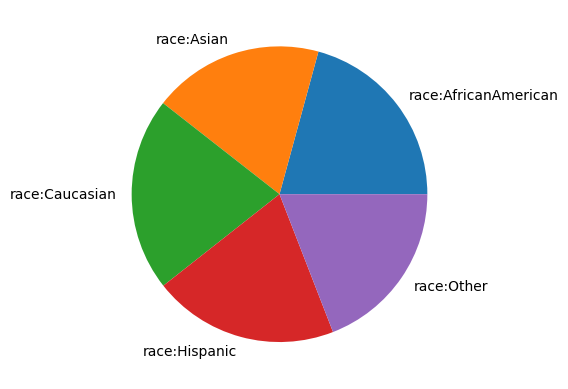

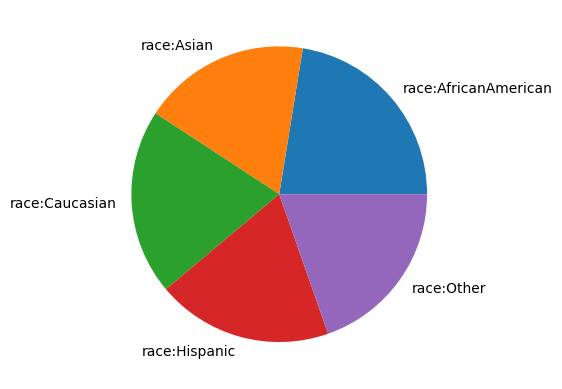

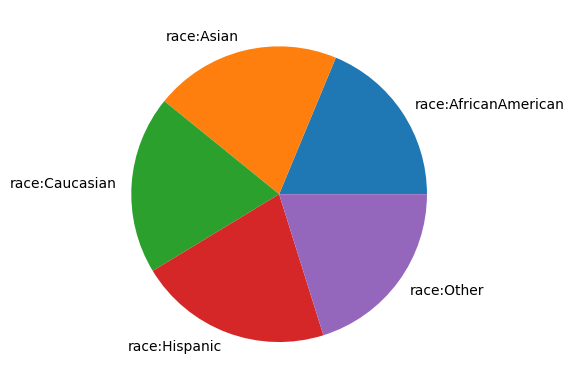

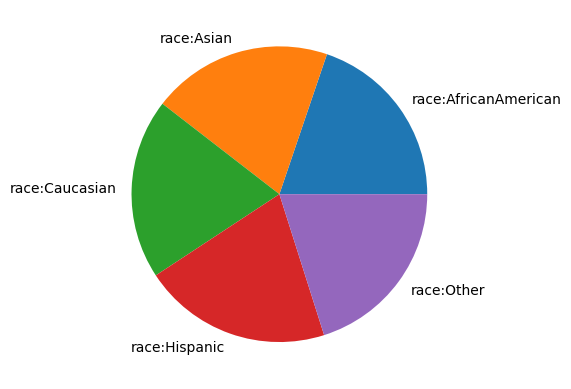

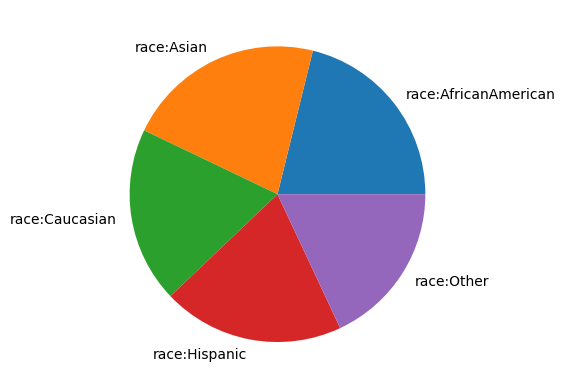

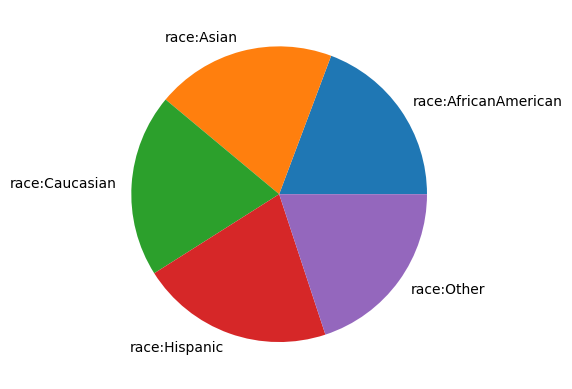

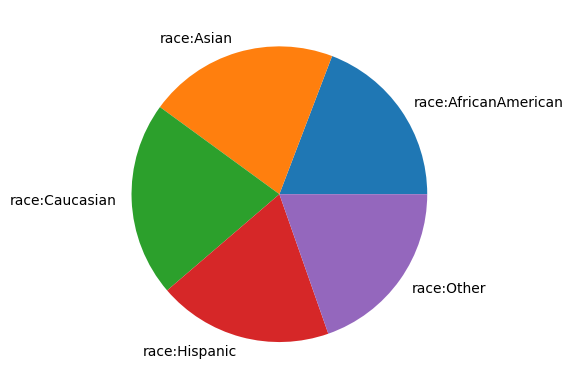

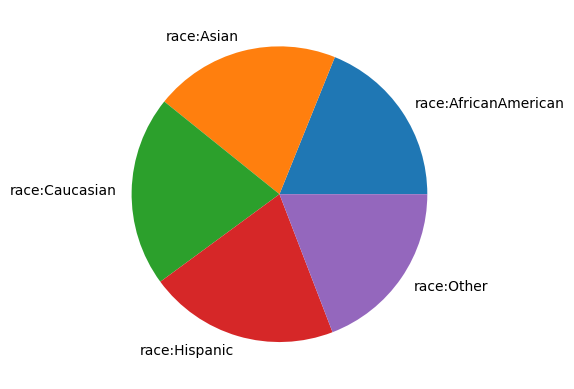

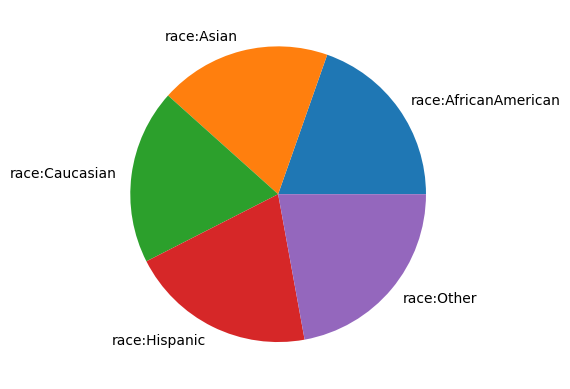

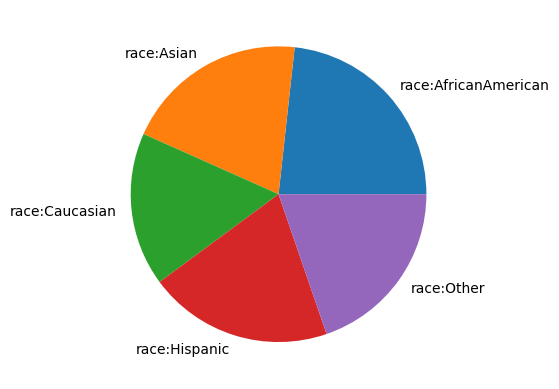

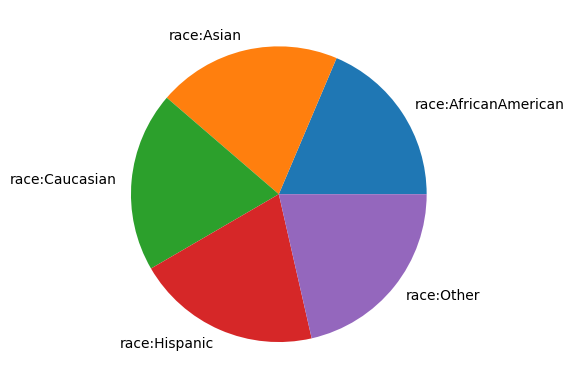

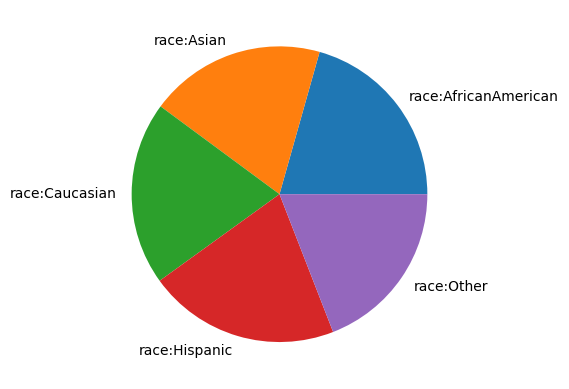

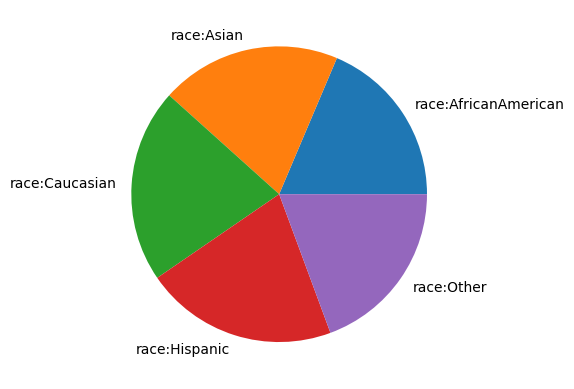

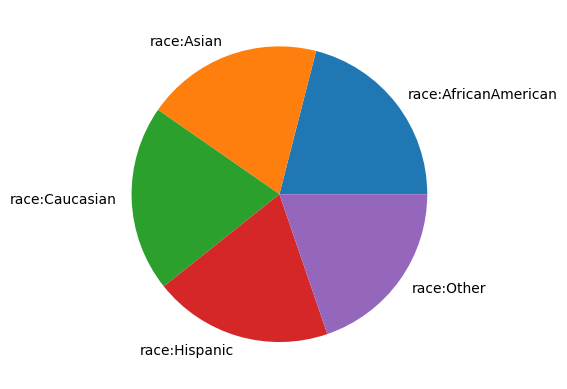

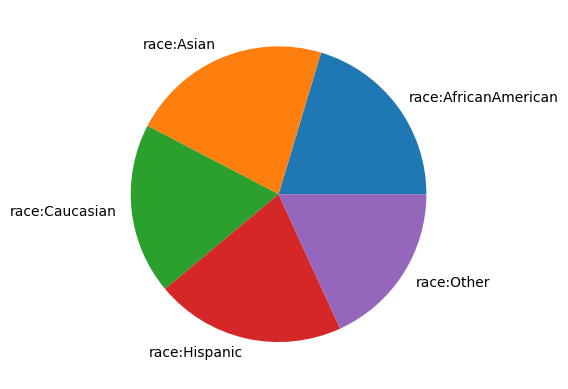

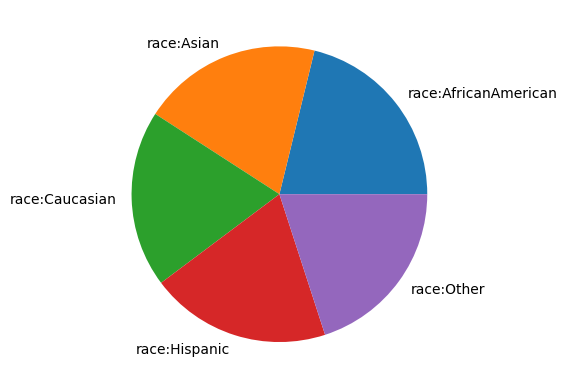

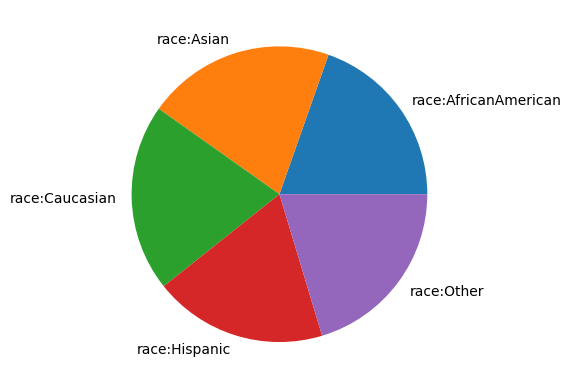

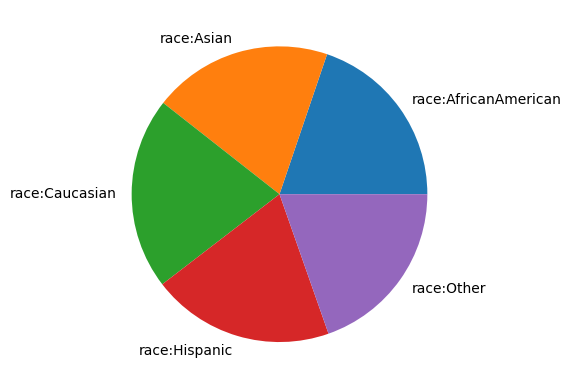

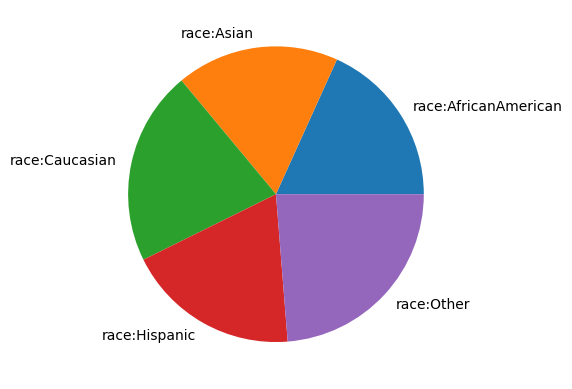

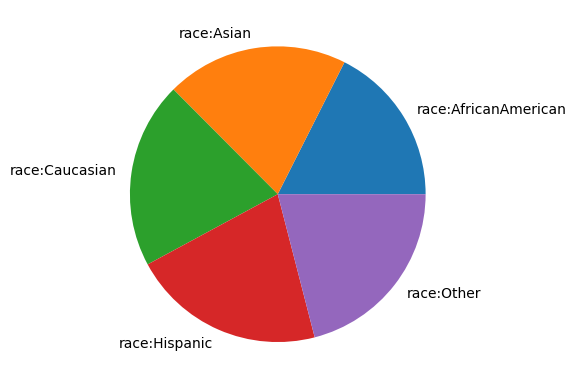

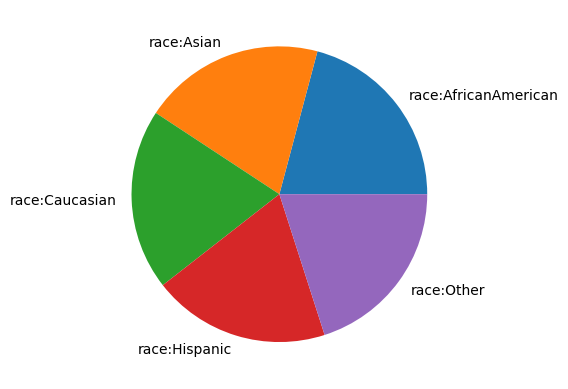

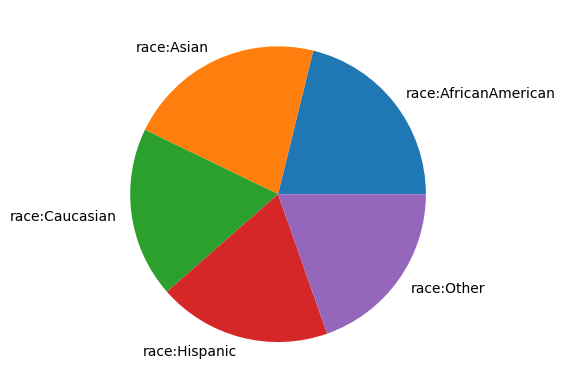

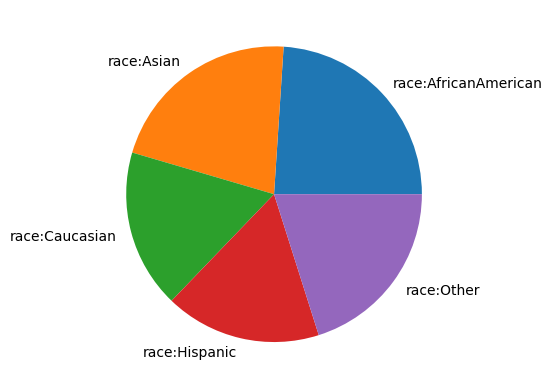

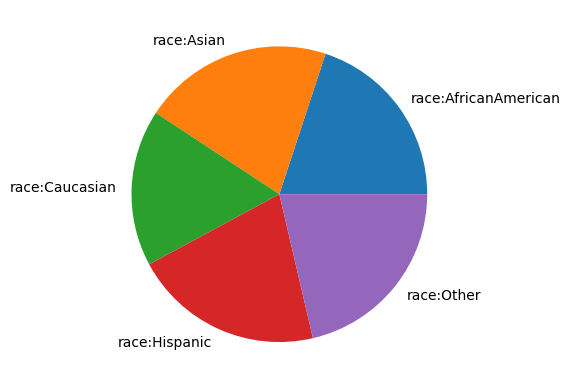

In [ ]:
race_columns = ["race:AfricanAmerican", "race:Asian", "race:Caucasian", "race:Hispanic", "race:Other"]
for location in all_locations:
  diabetes_df = df[df["diabetes"] == 0]
  diabetes_df = diabetes_df[diabetes_df["location"] == location]

  diabetes_df_race = diabetes_df[race_columns]

  values = []
  for race in race_columns:
    values.append(diabetes_df_race[race].sum())

  plt.pie(values, labels=race_columns)
  plt.show()

<Axes: >

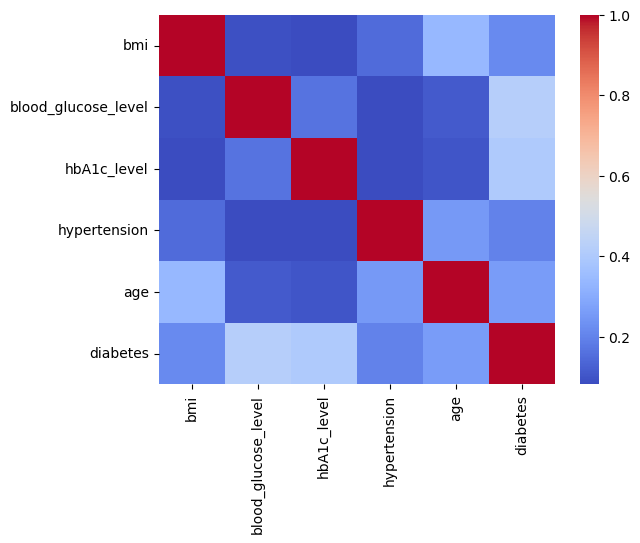

In [83]:
columns_i_want = ["bmi", "blood_glucose_level", "hbA1c_level", "hypertension", "age", "diabetes"]
new_df = df[columns_i_want]
correlation = new_df.corr()
sns.heatmap(correlation, cmap="coolwarm")

In [74]:
def get_total_by_location(df, location):
    total_diabetic, total_non_diabetic = 0, 0

    for i in range(len(df)):
      row = df.iloc[i]
      if row["location"] == location:
        if row["diabetes"] == 1:
          total_diabetic += 1
        else:
          total_non_diabetic += 1
    return total_diabetic, total_non_diabetic

def plot_totals(diabetic, non_diabetic):
    labels = ["Diabetic", "Non Diabetic"]
    values = [diabetic, non_diabetic]

    plt.bar(labels, values)
    plt.show()


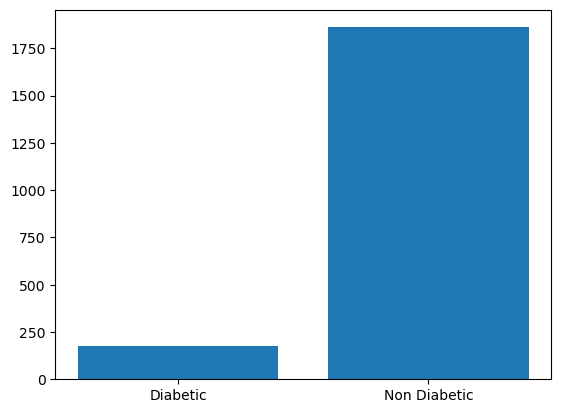

In [70]:
total_diabetic, total_non_diabetic = get_total_by_location(df, "Alabama")
plot_totals(total_diabetic, total_non_diabetic)

In [17]:
total_diabetes = 0
total_not_diabetes = 0

for value in df["diabetes"]:
  if value == 1:
    total_diabetes = total_diabetes + 1
  else:
    total_not_diabetes = total_not_diabetes + 1

8500 91500


In [ ]:
for location in all_locations:
  df_location = df[df["location"]==location]
  print(df_location.diabetes.nunique())


diabetes
0    1861
1     175
Name: count, dtype: int64
diabetes
0    1862
1     173
Name: count, dtype: int64
diabetes
0    1846
1     140
Name: count, dtype: int64
diabetes
0    1864
1     173
Name: count, dtype: int64
diabetes
0    1825
1     161
Name: count, dtype: int64
diabetes
0    1872
1     163
Name: count, dtype: int64
diabetes
0    1855
1     180
Name: count, dtype: int64
diabetes
0    1836
1     200
Name: count, dtype: int64
diabetes
0    1858
1     178
Name: count, dtype: int64
diabetes
0    1861
1     176
Name: count, dtype: int64
diabetes
0    1864
1     172
Name: count, dtype: int64
diabetes
0    1094
1     110
Name: count, dtype: int64
diabetes
0    1852
1     186
Name: count, dtype: int64
diabetes
0    1839
1     149
Name: count, dtype: int64
diabetes
0    1841
1     195
Name: count, dtype: int64
diabetes
0    1820
1     167
Name: count, dtype: int64
diabetes
0    1876
1     162
Name: count, dtype: int64
diabetes
0    1837
1     199
Name: count, dtype: int64
diabetes
0

In [ ]:

all_locations = df["location"].unique()
total_diabetes = []
total_non_diabetes = []

for location in all_locations:
  local_diabetes = 0
  local_non_diabetes = 0

  for i in range(len(df)):
    row = df.iloc[i]
    if row["location"] == location:
      # add to total
      if row["diabetes"] == 1:
        local_diabetes += 1
      else:
        local_non_diabetes += 1
  total_diabetes.append(local_diabetes)
  total_non_diabetes.append(local_non_diabetes)
  print(local_diabetes, local_non_diabetes)


  #   print("from alabama")
  # if row["diabetes"] == 1:
  #   print("diabetic")


# for i in range(len(df)):
#   row = df.iloc[i]
#   print(row["location"], row["diabetes"])

175 1861
173 1862
140 1846
173 1864
161 1825
163 1872
180 1855
200 1836
178 1858
176 1861
172 1864
110 1094
186 1852
149 1839
195 1841
167 1820
162 1876
199 1837
192 1846
167 1869
170 1866
184 1851
159 1877
173 1863
172 1865
184 1851
167 1868
194 1839
175 1863
169 1817
151 1884
163 1874
184 1849
140 1895
160 1875
177 1858
155 1831
142 1844
167 1869
170 1866
104 1191
192 1843
159 1828
158 1875
146 1428
109 1228
131 1270
120 1239
125 1213
72 691
125 1225
121 1242
107 1025
25 363
32 356


In [19]:
df.location.unique()

<StringArray>
[             'Alabama',               'Alaska',              'Arizona',
             'Arkansas',           'California',             'Colorado',
          'Connecticut',             'Delaware', 'District of Columbia',
              'Florida',              'Georgia',                 'Guam',
               'Hawaii',                'Idaho',             'Illinois',
              'Indiana',                 'Iowa',               'Kansas',
             'Kentucky',            'Louisiana',                'Maine',
             'Maryland',        'Massachusetts',             'Michigan',
            'Minnesota',          'Mississippi',             'Missouri',
              'Montana',             'Nebraska',               'Nevada',
        'New Hampshire',           'New Jersey',           'New Mexico',
             'New York',       'North Carolina',         'North Dakota',
                 'Ohio',             'Oklahoma',               'Oregon',
         'Pennsylvania',          'Pu

In [6]:
df.head(10)

,year,gender,age,location,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes
0,2020,Female,32.0,Alabama,0,0,0,0,1,0,0,never,27.32,5.0,100,0
1,2015,Female,29.0,Alabama,0,1,0,0,0,0,0,never,19.95,5.0,90,0
2,2015,Male,18.0,Alabama,0,0,0,0,1,0,0,never,23.76,4.8,160,0
3,2015,Male,41.0,Alabama,0,0,1,0,0,0,0,never,27.32,4.0,159,0
4,2016,Female,52.0,Alabama,1,0,0,0,0,0,0,never,23.75,6.5,90,0
5,2016,Male,66.0,Alabama,0,0,1,0,0,0,0,not current,27.32,5.7,159,0
6,2015,Female,49.0,Alabama,0,0,1,0,0,0,0,current,24.34,5.7,80,0
7,2016,Female,15.0,Alabama,0,0,0,0,1,0,0,No Info,20.98,5.0,155,0
8,2016,Male,51.0,Alabama,1,0,0,0,0,0,0,never,38.14,6.0,100,0
9,2015,Male,42.0,Alabama,0,0,1,0,0,0,0,No Info,27.32,5.7,160,0


<Axes: >

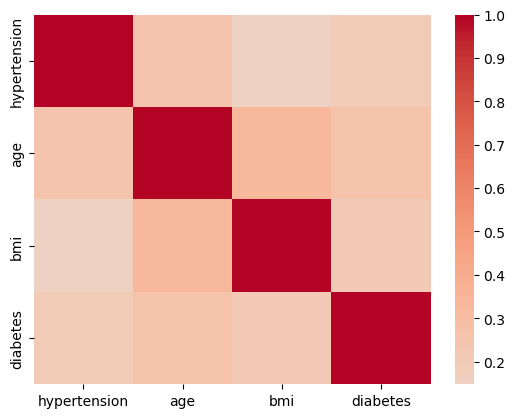

In [49]:
correlation = df[["hypertension", "age", "bmi", "diabetes"]].corr()


sns.heatmap(correlation, center=0, cmap="coolwarm")

In [5]:

df.describe(include="all")

,year,gender,age,location,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000,100000.000000,100000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.00000,100000.000000,100000,100000.000000,100000.000000,100000.000000,100000.000000
unique,NaN,3,NaN,55,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6,NaN,NaN,NaN,NaN
top,NaN,Female,NaN,Hawaii,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No Info,NaN,NaN,NaN,NaN
freq,NaN,58552,NaN,2038,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35816,NaN,NaN,NaN,NaN
mean,2018.360820,NaN,41.885856,NaN,0.202230,0.200150,0.198760,0.19888,0.199980,0.07485,0.039420,NaN,27.320767,5.527507,138.058060,0.085000
std,1.345239,NaN,22.516840,NaN,0.401665,0.400114,0.399069,0.39916,0.399987,0.26315,0.194593,NaN,6.636783,1.070672,40.708136,0.278883
min,2015.000000,NaN,0.080000,NaN,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,NaN,10.010000,3.500000,80.000000,0.000000
25%,2019.000000,NaN,24.000000,NaN,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,NaN,23.630000,4.800000,100.000000,0.000000
50%,2019.000000,NaN,43.000000,NaN,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,NaN,27.320000,5.800000,140.000000,0.000000
75%,2019.000000,NaN,60.000000,NaN,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,NaN,29.580000,6.200000,159.000000,0.000000


In [6]:

df.isna().sum().sort_values(ascending=False)

year                    0
gender                  0
age                     0
location                0
race:AfricanAmerican    0
race:Asian              0
race:Caucasian          0
race:Hispanic           0
race:Other              0
hypertension            0
heart_disease           0
smoking_history         0
bmi                     0
hbA1c_level             0
blood_glucose_level     0
diabetes                0
dtype: int64

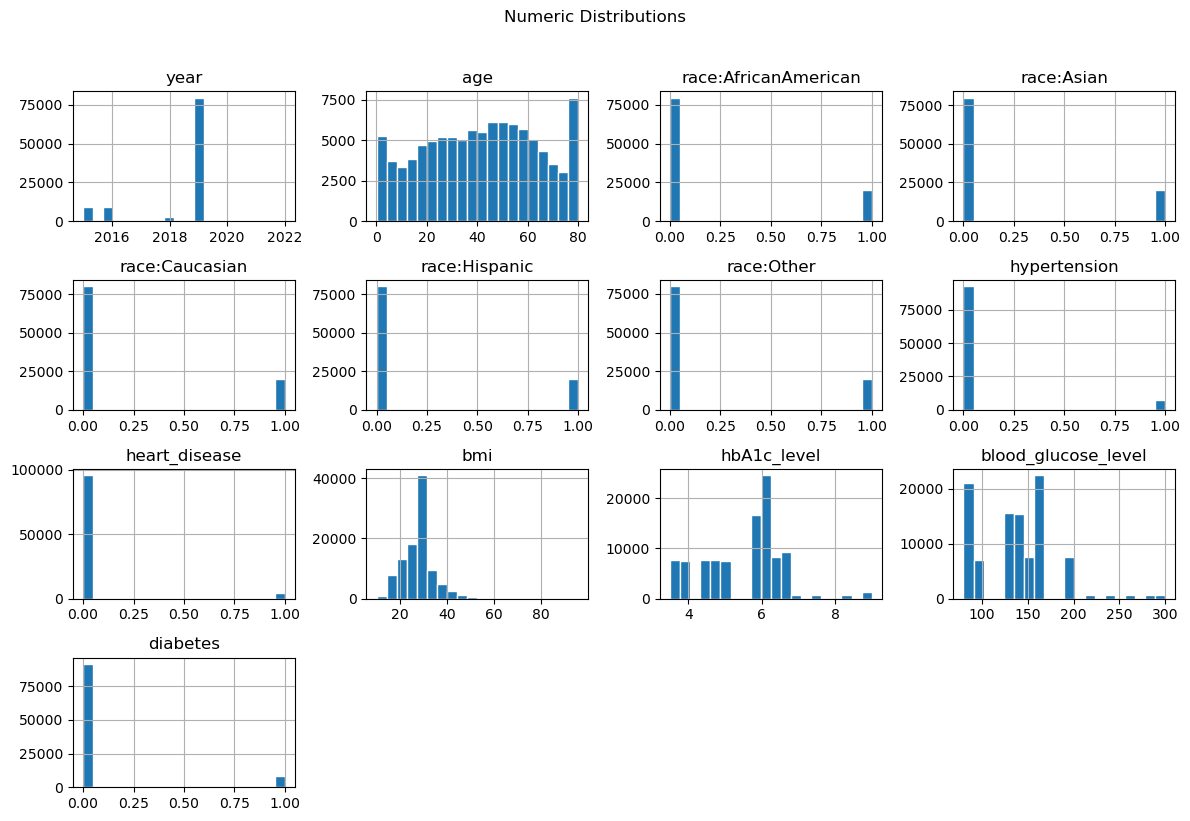

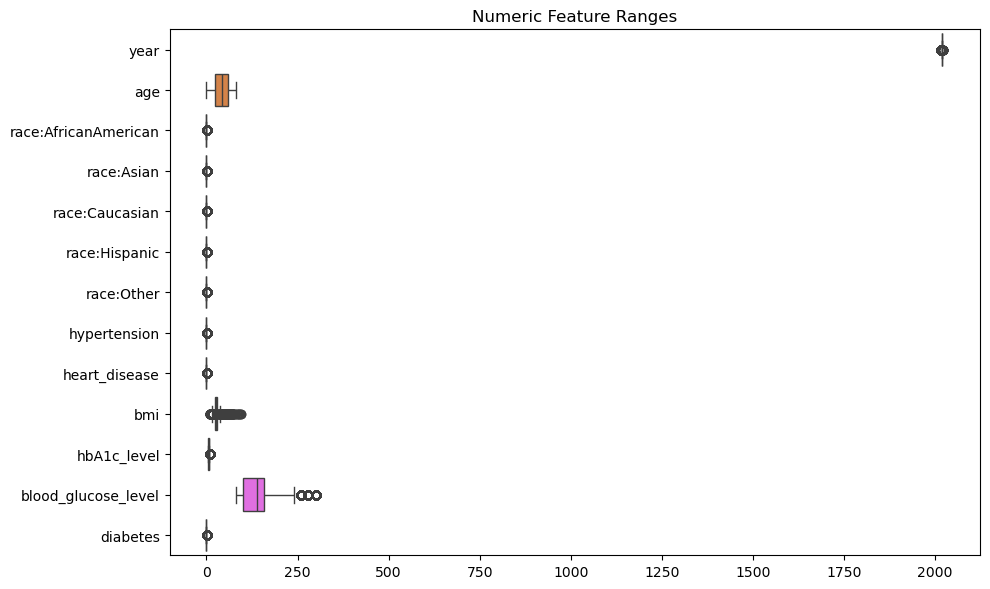

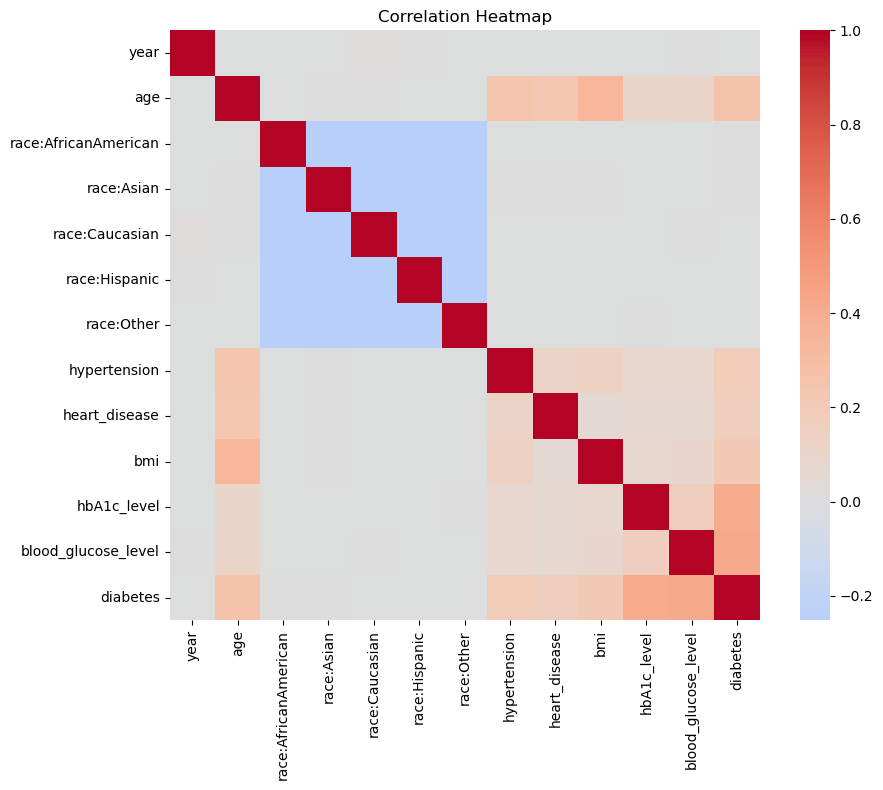

In [7]:

numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()

if numeric_cols:
    df[numeric_cols].hist(figsize=(12, 8), bins=20, edgecolor="white")
    plt.suptitle("Numeric Distributions", y=1.02)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df[numeric_cols], orient="h")
    plt.title("Numeric Feature Ranges")
    plt.tight_layout()
    plt.show()

    corr = df[numeric_cols].corr(numeric_only=True)
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, cmap="coolwarm", center=0, square=True)
    plt.title("Correlation Heatmap")
    plt.tight_layout()
    plt.show()

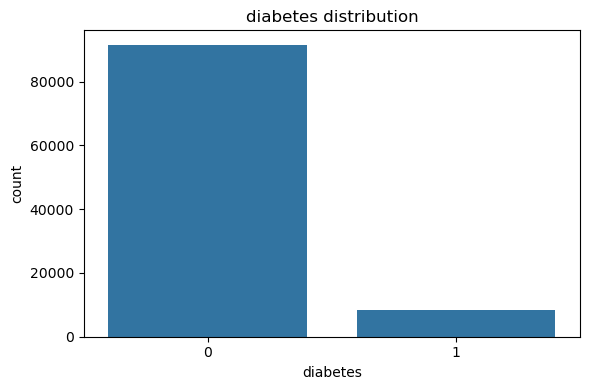

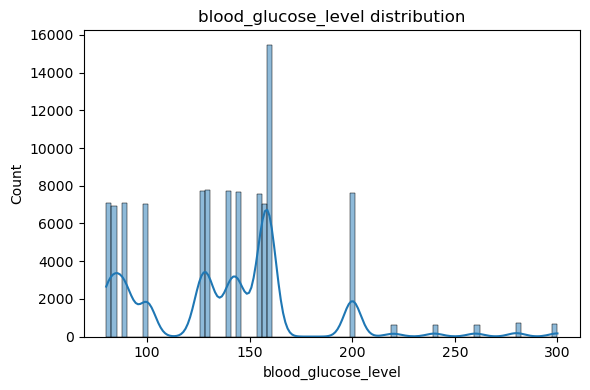

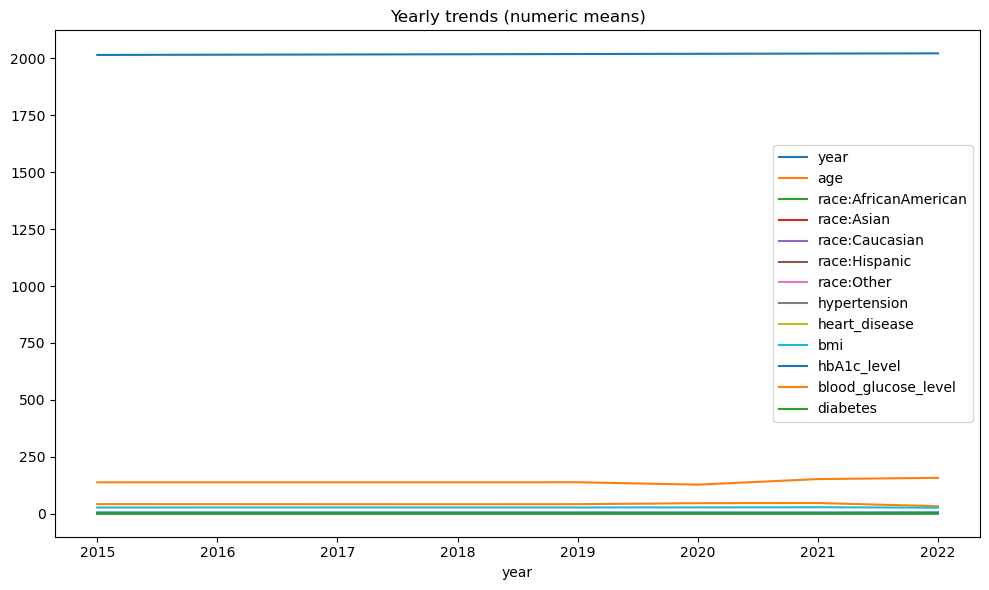

In [8]:

possible_target = [c for c in ["diabetes", "diabetes_binary", "Outcome", "Diabetes"] if c in df.columns]
if possible_target:
    target = possible_target[0]
    plt.figure(figsize=(6, 4))
    sns.countplot(x=target, data=df)
    plt.title(f"{target} distribution")
    plt.tight_layout()
    plt.show()

for col in ["BMI", "HbA1c_level", "blood_glucose_level", "glucose"]:
    if col in df.columns:
        plt.figure(figsize=(6, 4))
        sns.histplot(data=df, x=col, kde=True)
        plt.title(f"{col} distribution")
        plt.tight_layout()
        plt.show()

for col in ["year", "Year"]:
    if col in df.columns:
        yearly = df.groupby(col)[numeric_cols].mean(numeric_only=True)
        yearly.plot(figsize=(10, 6))
        plt.title("Yearly trends (numeric means)")
        plt.tight_layout()
        plt.show()
        break


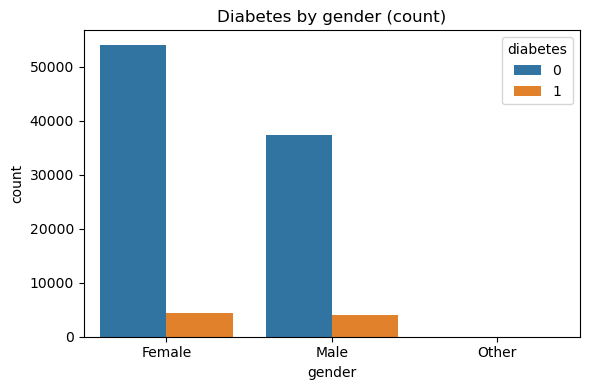

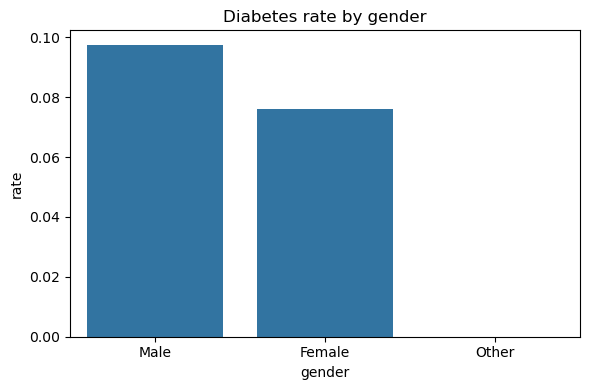

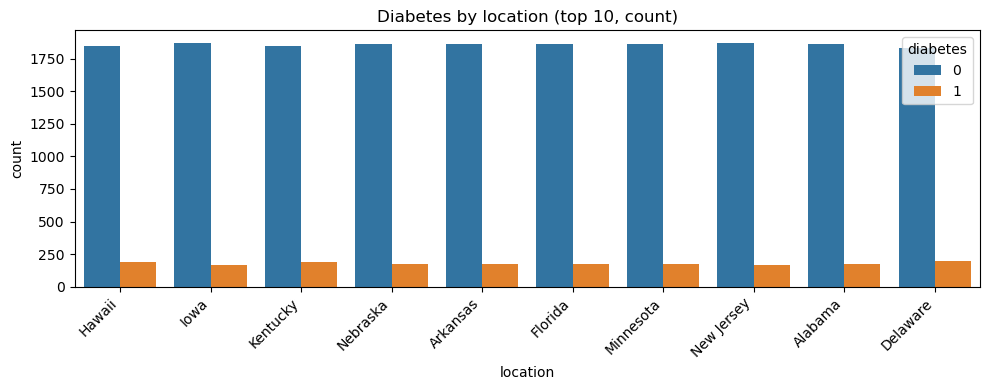

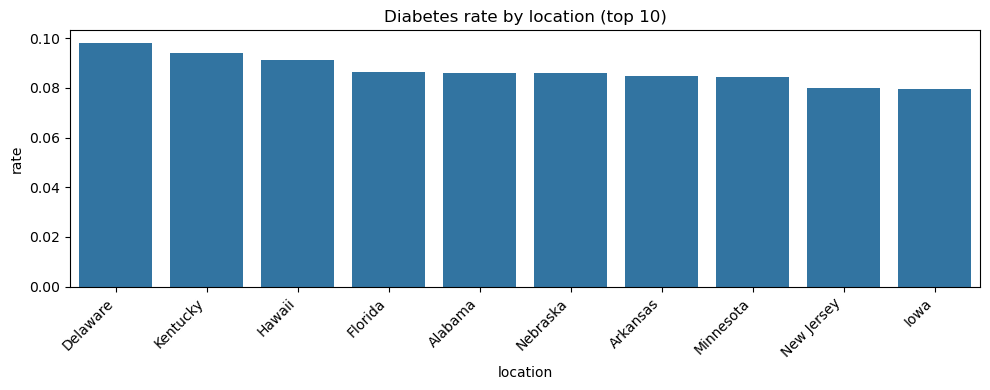

In [9]:
if "gender" in df.columns and "diabetes" in df.columns:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x="gender", hue="diabetes")
    plt.title("Diabetes by gender (count)")
    plt.tight_layout()
    plt.show()

    gender_rate = df.groupby("gender")["diabetes"].mean().sort_values(ascending=False)
    plt.figure(figsize=(6, 4))
    sns.barplot(x=gender_rate.index, y=gender_rate.values)
    plt.title("Diabetes rate by gender")
    plt.ylabel("rate")
    plt.tight_layout()
    plt.show()

if "location" in df.columns and "diabetes" in df.columns:
    top_locations = df["location"].value_counts().head(10).index
    loc_df = df[df["location"].isin(top_locations)]

    plt.figure(figsize=(10, 4))
    sns.countplot(data=loc_df, x="location", hue="diabetes", order=top_locations)
    plt.title("Diabetes by location (top 10, count)")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    loc_rate = df.groupby("location")["diabetes"].mean().loc[top_locations].sort_values(ascending=False)
    plt.figure(figsize=(10, 4))
    sns.barplot(x=loc_rate.index, y=loc_rate.values)
    plt.title("Diabetes rate by location (top 10)")
    plt.ylabel("rate")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


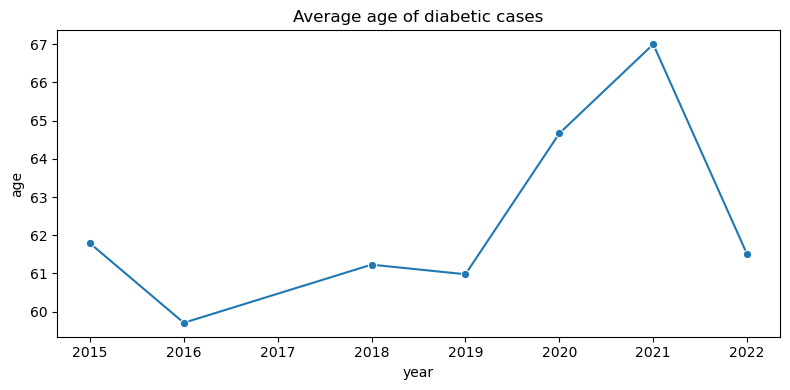

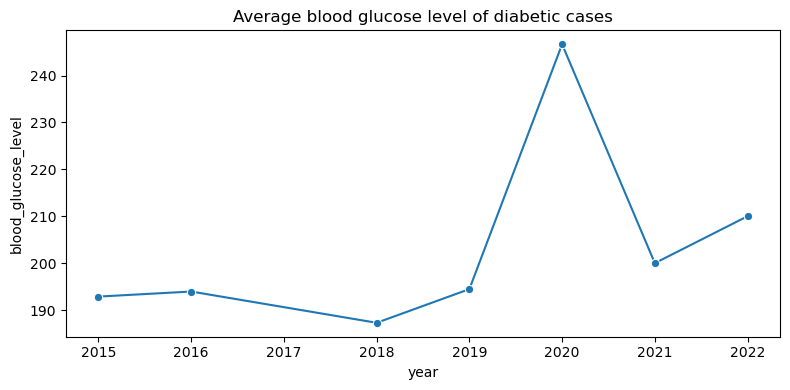

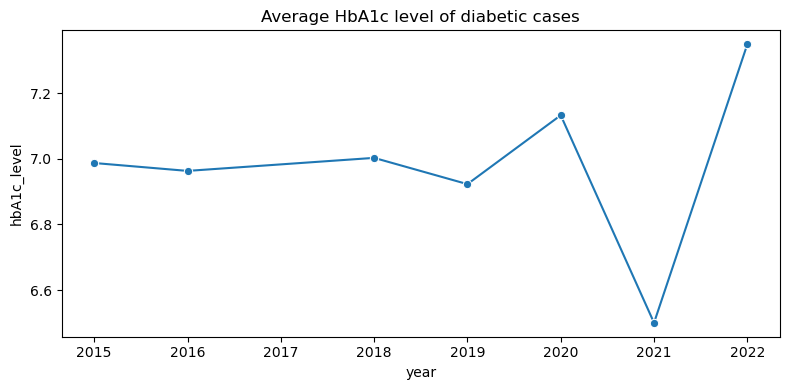

In [10]:
if "diabetes" in df.columns and "year" in df.columns:
    diabetic = df[df["diabetes"] == 1]

    if "age" in df.columns:
        avg_age = diabetic.groupby("year")["age"].mean()
        plt.figure(figsize=(8, 4))
        sns.lineplot(x=avg_age.index, y=avg_age.values, marker="o")
        plt.title("Average age of diabetic cases")
        plt.xlabel("year")
        plt.ylabel("age")
        plt.tight_layout()
        plt.show()

    if "blood_glucose_level" in df.columns:
        avg_glucose = diabetic.groupby("year")["blood_glucose_level"].mean()
        plt.figure(figsize=(8, 4))
        sns.lineplot(x=avg_glucose.index, y=avg_glucose.values, marker="o")
        plt.title("Average blood glucose level of diabetic cases")
        plt.xlabel("year")
        plt.ylabel("blood_glucose_level")
        plt.tight_layout()
        plt.show()

    if "hbA1c_level" in df.columns:
        avg_hba1c = diabetic.groupby("year")["hbA1c_level"].mean()
        plt.figure(figsize=(8, 4))
        sns.lineplot(x=avg_hba1c.index, y=avg_hba1c.values, marker="o")
        plt.title("Average HbA1c level of diabetic cases")
        plt.xlabel("year")
        plt.ylabel("hbA1c_level")
        plt.tight_layout()
        plt.show()


# Decision Tree (sklearn)

Medical students: this section shows a simple clinical prediction workflow.

- **Goal**: predict diabetes (0/1) from available features.
- **Pandas**: select columns and inspect basic shapes.
- **Train/test split**: hold out data to estimate real‑world performance.
- **One‑hot encoding**: convert categories like gender or location to numbers.
- **Decision tree**: a simple, interpretable baseline model for binary outcomes.

Interpretation tips:
- Accuracy is overall correctness.
- ROC AUC reflects discrimination across thresholds.
- Feature importance shows which variables the tree used most (not causation).


Accuracy: 0.961
ROC AUC: 0.961687849566056
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     18300
           1       0.87      0.64      0.74      1700

    accuracy                           0.96     20000
   macro avg       0.92      0.81      0.86     20000
weighted avg       0.96      0.96      0.96     20000



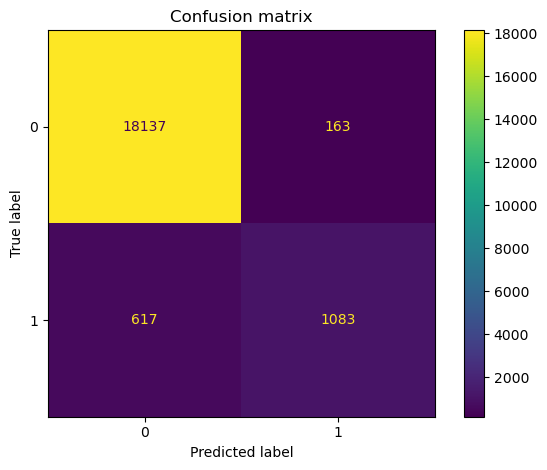

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, ConfusionMatrixDisplay

if "diabetes" in df.columns:
    X = df.drop(columns=["diabetes"])
    y = df["diabetes"]

    categorical_cols = X.select_dtypes(include=["object", "category", "string"]).columns
    numeric_cols_dt = X.columns.difference(categorical_cols)

    preprocessor = ColumnTransformer(
        [
            ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
            ("num", "passthrough", numeric_cols_dt),
        ]
    )

    model = DecisionTreeClassifier(random_state=42)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    clf = Pipeline(
        steps=[
            ("preprocess", preprocessor),
            ("model", model),
        ]
    )

    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    y_prob = clf.predict_proba(X_test)[:, 1]

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("ROC AUC:", roc_auc_score(y_test, y_prob))
    print(classification_report(y_test, y_pred))

    ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
    plt.title("Confusion matrix")
    plt.tight_layout()
    plt.show()

    feature_names = clf.named_steps["preprocess"].get_feature_names_out()
    importances = clf.named_steps["model"].feature_importances_
    top_idx = importances.argsort()[-10:][::-1]

    plt.figure(figsize=(8, 4))
    plt.barh(feature_names[top_idx][::-1], importances[top_idx][::-1])
    plt.title("Top 10 feature importances")
    plt.tight_layout()
    plt.show()
